# ChemBERTa Tokenizer Audit para SLICES de Alexandria

## Pregunta científica

> ¿Puede el tokenizer original de ChemBERTa codificar de forma eficiente las representaciones cristalinas SLICES, o conviene adaptar el tokenizer antes de continuar el preentrenamiento en el dominio?

Este notebook reúne evidencia **no supervisada** sobre cobertura, fragmentación, longitud de secuencias, ventana de contexto y manejo de tokens SLICES. El dataset contiene una cadena `slices` por estructura y metadata descriptiva. No se leen ni utilizan targets energéticos.

**Alcance:** se carga el tokenizer y la configuración del checkpoint; no se carga ningún modelo. No se entrena MLM/DAPT, no se hace fine-tuning, no se añade vocabulario, no se redimensionan embeddings, no se modifica ni guarda un tokenizer, y no se construye el dataset definitivo de polimorfos.

**Decisiones que este audit debe informar:** mantener el tokenizer original, evaluar una extensión del vocabulario o investigar un tokenizer específico de SLICES. La recomendación final es heurística y no sustituye una evaluación empírica de DAPT.

### Qué mide cada familia de resultados

- **Longitud:** cuántos IDs produce el tokenizer por estructura, con y sin tokens especiales; sirve para cuantificar riesgo de exceder el contexto.
- **Fertilidad:** número de subtokens ChemBERTa por token léxico SLICES, tanto por secuencia como ponderado por las ocurrencias; mide fragmentación.
- **Cobertura y `[UNK]`:** tokens del vocabulario observados y presencia de tokens desconocidos. Cero `[UNK]` no implica fragmentación eficiente.
- **Análisis léxico por clase:** inspecciona símbolos de elementos, índices enteros y direcciones periódicas/jimage.
- **Relación con tamaño:** compara tokens y `nsites` sin atribuir causalidad.
- **Simulación de truncamiento:** estima contenido que se perdería con distintos límites; no trunca ni modifica el dataset.

El checkpoint inicial es `seyonec/ChemBERTa-zinc-base-v1`, siguiendo el modelo ChemBERTa publicado en Hugging Face. Debe cambiarse si el checkpoint de DAPT del proyecto es otro. El modelo y sus ficheros tokenizer están en [Hugging Face](https://huggingface.co/seyonec/ChemBERTa-zinc-base-v1).


## 1. Project paths

La raíz se detecta buscando hacia arriba una carpeta que contenga `data/`. Así se puede lanzar Jupyter desde la raíz del proyecto o desde `audit/notebooks/`. Este notebook y todos sus reportes se guardan bajo `audit/notebooks/`; `audit/` queda al mismo nivel que `data/`.

In [1]:
from pathlib import Path
from datetime import datetime

def find_project_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
AUDIT_DIR = PROJECT_ROOT / "audit"
NOTEBOOK_DIR = AUDIT_DIR / "notebooks"
OUTPUT_ROOT = NOTEBOOK_DIR / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
if any(OUTPUT_ROOT.iterdir()):
    run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = OUTPUT_ROOT / f"run_{run_stamp}"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print("Outputs previos preservados; esta ejecución usará:", OUTPUT_DIR)
else:
    OUTPUT_DIR = OUTPUT_ROOT
FIGURES_DIR = OUTPUT_DIR

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Audit directory:", AUDIT_DIR)
print("Notebook directory:", NOTEBOOK_DIR)
print("Output directory:", OUTPUT_ROOT)


Outputs previos preservados; esta ejecución usará: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/audit/notebooks/outputs/run_20261005_220042
Project root: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis
Data directory: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data
Audit directory: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/audit
Notebook directory: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/audit/notebooks
Output directory: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/audit/notebooks/outputs


## 2. Configuration

`MODEL_NAME` debe coincidir exactamente con el checkpoint que se usará después para DAPT. No se conoce en el proyecto otro checkpoint seleccionado explícitamente, por eso se usa el valor inicial indicado.

**Selección del CSV:** si el dataset se encuentra en más de una ruta, el código se detiene y enumera las opciones; no elige una copia arbitrariamente. El override visible de abajo apunta a la salida `alexandria_clean_all.csv` generada por la etapa de limpieza en este workspace. Cámbialo a `None` para activar la búsqueda automática, o asigna explícitamente otra ruta.

El override solo selecciona el archivo de entrada; nunca se modifica. Los outputs preexistentes tampoco se sobrescriben: se crea una carpeta `run_YYYYMMDD_HHMMSS/` cuando haya colisiones.

In [2]:
import os
import re
import sys
import json
import math
import importlib.util
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
MODEL_REVISION = None  # Opcional: fijar un commit de Hugging Face para reproducibilidad estricta.
RANDOM_SEED = 42
BATCH_SIZE = 512
MAX_EXAMPLE_ROWS = 500
TOP_N_TOKENS = 500
CANDIDATE_MIN_FREQUENCY = 10
THRESHOLDS = [64, 128, 256, 384, 512, 768, 1024, 1536, 2048]
TRUNCATION_LIMITS = [128, 256, 512, 1024]

# Selección deliberada: evitar escoger una copia de alexandria_clean_all.csv al azar.
_known_clean_output = DATA_DIR / "notebooks_processing" / "outputs" / "alexandria_clean_all.csv"
MANUAL_INPUT_CSV = _known_clean_output if _known_clean_output.is_file() else None

REQUIRED_COLUMNS = ["mat_id", "slices", "composition_key", "nsites"]
OPTIONAL_METADATA_COLUMNS = ["reduced_formula", "n_elements", "spg"]


## 3. Find and load the cleaned Alexandria dataset

La búsqueda automática revisa primero las rutas convencionales y después el resto de `data/`. Si encuentra más de una coincidencia con el nombre preferido, requiere que `MANUAL_INPUT_CSV` señale explícitamente cuál usar.

Se leen solamente `mat_id`, `slices`, `composition_key`, `nsites` y metadata opcional (`reduced_formula`, `n_elements`, `spg`). Los targets energéticos no se cargan ni participan en este análisis.

In [3]:
def find_clean_dataset(project_root, manual_path=None):
    if manual_path is not None:
        manual_path = Path(manual_path).expanduser()
        if not manual_path.is_absolute():
            manual_path = (project_root / manual_path).resolve()
        if not manual_path.is_file():
            raise FileNotFoundError(f"MANUAL_INPUT_CSV no existe: {manual_path}")
        return manual_path

    conventional = [
        project_root / "data" / "alexandria_clean_all.csv",
        project_root / "data" / "cleaned" / "alexandria_clean_all.csv",
    ]
    existing_conventional = [path.resolve() for path in conventional if path.is_file()]
    all_matches = sorted({path.resolve() for path in (project_root / "data").rglob("alexandria_clean_all.csv")})
    if len(all_matches) > 1:
        paths = "\n".join(f"- {path}" for path in all_matches)
        raise RuntimeError(
            "Hay varias copias de alexandria_clean_all.csv. Asigna MANUAL_INPUT_CSV "
            f"explícitamente. Coincidencias:\n{paths}"
        )
    if len(all_matches) == 1:
        return all_matches[0]
    raise FileNotFoundError(
        "No se encontró alexandria_clean_all.csv en data/. "
        "Configura MANUAL_INPUT_CSV con la ruta correcta."
    )

INPUT_CSV = find_clean_dataset(PROJECT_ROOT, MANUAL_INPUT_CSV)
source_columns = pd.read_csv(INPUT_CSV, nrows=0).columns.tolist()
missing_columns = [column for column in REQUIRED_COLUMNS if column not in source_columns]
if missing_columns:
    raise ValueError(f"El CSV no tiene las columnas requeridas: {missing_columns}")
columns_to_load = REQUIRED_COLUMNS + [
    column for column in OPTIONAL_METADATA_COLUMNS if column in source_columns
]
df = pd.read_csv(INPUT_CSV, usecols=columns_to_load, low_memory=False)

print("Dataset:", INPUT_CSV)
print("CSV original columns:", len(source_columns))
print("Columnas cargadas para el audit (sin targets energéticos):", df.columns.tolist())
print("Shape cargado:", df.shape)
print("Memory usage (MB):", round(df.memory_usage(index=True, deep=True).sum() / 1_000_000, 2))
print("mat_id duplicados:", int(df["mat_id"].duplicated(keep=False).sum()))
print("SLICES duplicados:", int(df["slices"].duplicated(keep=False).sum()))
print("SLICES nulos:", int(df["slices"].isna().sum()))
print("SLICES vacíos:", int(df["slices"].fillna("").astype(str).str.strip().eq("").sum()))


Dataset: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/notebooks_processing/outputs/alexandria_clean_all.csv
CSV original columns: 85
Columnas cargadas para el audit (sin targets energéticos): ['mat_id', 'reduced_formula', 'composition_key', 'n_elements', 'spg', 'nsites', 'slices']
Shape cargado: (99998, 7)
Memory usage (MB): 69.33
mat_id duplicados: 0
SLICES duplicados: 0
SLICES nulos: 0
SLICES vacíos: 0


## 4. Reproducibility and software versions

Se registran las versiones que pueden afectar al tokenizador y la construcción de tablas. `RANDOM_SEED` solo controla submuestreos de gráficos; las métricas principales usan todas las filas y son deterministas.

In [4]:
import transformers
from transformers import AutoTokenizer, AutoConfig
from transformers.utils import logging as hf_logging

print("Python:", sys.version)
print("Transformers:", transformers.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Model/tokenizer:", MODEL_NAME)
print("Model revision requested:", MODEL_REVISION)
np.random.seed(RANDOM_SEED)


Python: 3.10.21 | packaged by conda-forge | (main, Aug 21 2026, 22:37:53) [Clang 19.1.7 ]
Transformers: 5.17.0
Pandas: 2.3.3
NumPy: 2.2.6
Model/tokenizer: seyonec/ChemBERTa-zinc-base-v1
Model revision requested: None


## 5. Minimal SLICES normalization and input validation

Solo entran filas cuyo `slices` no es nulo ni vacío. Se crea `slices_normalized` compactando whitespace; `slices` en el CSV fuente nunca se sobrescribe. No se cambian caracteres ni tokens. Las longitudes lexical y de caracteres se calculan antes de tokenizar ChemBERTa.

In [5]:
valid_slices_mask = df["slices"].notna() & df["slices"].astype("string").str.strip().ne("")
df_audit = df.loc[valid_slices_mask].copy().reset_index(drop=False).rename(columns={"index": "source_row_index"})

def normalize_slices(text):
    return " ".join(str(text).split())

df_audit["slices_normalized"] = df_audit["slices"].map(normalize_slices)
df_audit = df_audit.loc[df_audit["slices_normalized"].ne("")].reset_index(drop=True)
df_audit["slices_char_length"] = df_audit["slices_normalized"].str.len().astype("int64")
df_audit["slices_whitespace_tokens"] = df_audit["slices_normalized"].map(lambda value: len(value.split())).astype("int64")

print("Filas con SLICES utilizable:", len(df_audit), "de", len(df))
print("SLICES source column overwritten:", False)
display(df_audit[["mat_id", "composition_key", "slices_char_length", "slices_whitespace_tokens"]].head())


Filas con SLICES utilizable: 99998 de 99998
SLICES source column overwritten: False


,mat_id,composition_key,slices_char_length,slices_whitespace_tokens
0,agm005737469,Cd10 Rh2 Sr1,760,270
1,agm002510391,Ca1 Li3 Pt1,188,70
2,agm004513860,Ga4 Nd2 Pt3 Ti1,517,193
3,agm003886200,Br2 Mn1 Sr1,173,65
4,agm034649907,Na2 Se6 Sm1 Tb3,353,127


## 6. Load the ChemBERTa tokenizer and config only

Se llama `AutoTokenizer.from_pretrained` y `AutoConfig.from_pretrained`. No se importa ni instancia `AutoModel`, `AutoModelForMaskedLM` ni `AutoModelForSequenceClassification`. El valor inicial sigue el checkpoint de ChemBERTa Zinc reportado por su model card; si la estrategia DAPT del proyecto usa otro checkpoint, actualiza `MODEL_NAME` antes de ejecutar.

In [6]:
load_kwargs = {}
if MODEL_REVISION is not None:
    load_kwargs["revision"] = MODEL_REVISION

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, **load_kwargs)
config = AutoConfig.from_pretrained(MODEL_NAME, **load_kwargs)

print("Tokenizer:")
display(tokenizer)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Tokenizer vocabulary size:", tokenizer.vocab_size)
print("Tokenizer reported model_max_length:", tokenizer.model_max_length)
print("Special tokens map:")
print(tokenizer.special_tokens_map)
print("Config max_position_embeddings:", getattr(config, "max_position_embeddings", None))
print("Resolved tokenizer revision:", getattr(tokenizer, "init_kwargs", {}).get("_commit_hash"))


Tokenizer:


RobertaTokenizer(name_or_path='seyonec/ChemBERTa-zinc-base-v1', vocab_size=767, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

Tokenizer class: RobertaTokenizer
Tokenizer vocabulary size: 767
Tokenizer reported model_max_length: 512
Special tokens map:
{'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}
Config max_position_embeddings: 514
Resolved tokenizer revision: None


## 7. Inspect special tokens and infer the usable context window

Los límites reportados por tokenizer y config se guardan separados. Algunos tokenizers usan un entero centinela muy grande para `model_max_length`; la función `is_reasonable_model_length` evita tratarlo como una ventana real. Si los dos límites son razonables, la referencia efectiva es el menor. Este cálculo es diagnóstico: no cambia el tokenizer ni activa truncamiento.

In [7]:
SPECIAL_TOKEN_ATTRIBUTES = [
    "pad_token", "unk_token", "mask_token", "cls_token", "sep_token", "bos_token", "eos_token"
]
special_token_rows = []
for attribute in SPECIAL_TOKEN_ATTRIBUTES:
    token = getattr(tokenizer, attribute, None)
    token_id = getattr(tokenizer, f"{attribute}_id", None)
    special_token_rows.append({"token_name": attribute, "token": token, "token_id": token_id})
special_tokens_table = pd.DataFrame(special_token_rows)
display(special_tokens_table)

def is_reasonable_model_length(value):
    try:
        value = int(value)
    except (TypeError, ValueError, OverflowError):
        return False
    return value > 0 and value < 1_000_000

tokenizer_model_max_length = getattr(tokenizer, "model_max_length", None)
config_max_position_embeddings = getattr(config, "max_position_embeddings", None)
reasonable_limits = [
    int(value) for value in (tokenizer_model_max_length, config_max_position_embeddings)
    if is_reasonable_model_length(value)
]
effective_context_limit = min(reasonable_limits) if reasonable_limits else None
context_window_table = pd.DataFrame([
    {"source": "tokenizer.model_max_length", "reported_value": tokenizer_model_max_length,
     "reasonable_limit": is_reasonable_model_length(tokenizer_model_max_length)},
    {"source": "config.max_position_embeddings", "reported_value": config_max_position_embeddings,
     "reasonable_limit": is_reasonable_model_length(config_max_position_embeddings)},
    {"source": "effective_context_limit", "reported_value": effective_context_limit,
     "reasonable_limit": effective_context_limit is not None},
])
display(context_window_table)
print("Effective context limit:", effective_context_limit)


,token_name,token,token_id
0,pad_token,<pad>,1
1,unk_token,<unk>,3
2,mask_token,<mask>,4
3,cls_token,<s>,0
4,sep_token,</s>,2
5,bos_token,<s>,0
6,eos_token,</s>,2


,source,reported_value,reasonable_limit
0,tokenizer.model_max_length,512,True
1,config.max_position_embeddings,514,True
2,effective_context_limit,512,True


Effective context limit: 512


## 8. Lexical analysis of SLICES

SLICES es naturalmente legible como tokens separados por espacios. Este análisis cuenta ocurrencias en todo el dataset antes de consultar ChemBERTa. La clasificación es deliberadamente simple y solo describe patrones léxicos; no intenta reemplazar ni reproducir el parser oficial de SLICES.

In [8]:
ELEMENT_PATTERN = re.compile(r"^[A-Z][a-z]?$")
INTEGER_PATTERN = re.compile(r"^\d+$")
PERIODIC_PATTERN = re.compile(r"^[o+\-]{3}$")

def classify_slices_token(token):
    if ELEMENT_PATTERN.fullmatch(token):
        return "element"
    if INTEGER_PATTERN.fullmatch(token):
        return "integer"
    if PERIODIC_PATTERN.fullmatch(token):
        return "periodic_direction"
    return "other"

slices_token_counter = Counter()
for text in df_audit["slices_normalized"]:
    slices_token_counter.update(text.split())

total_slices_lexical_tokens = int(sum(slices_token_counter.values()))
n_unique_slices_tokens = int(len(slices_token_counter))
top_slices_tokens = pd.DataFrame([
    {"token": token, "frequency": frequency,
     "percentage": 100 * frequency / total_slices_lexical_tokens,
     "token_type": classify_slices_token(token)}
    for token, frequency in slices_token_counter.most_common(TOP_N_TOKENS)
])
print("Total SLICES lexical token occurrences:", total_slices_lexical_tokens)
print("Unique SLICES lexical tokens:", n_unique_slices_tokens)
display(top_slices_tokens.head(30))


Total SLICES lexical token occurrences: 14664831
Unique SLICES lexical tokens: 320


,token,frequency,percentage,token_type
0,ooo,1558575,10.627978,periodic_direction
1,0,1015470,6.924526,integer
2,1,976388,6.658024,integer
3,2,936967,6.389211,integer
4,3,902502,6.154193,integer
5,4,653939,4.459233,integer
6,5,539571,3.679354,integer
7,6,460964,3.143330,integer
8,7,430143,2.933160,integer
9,+oo,382782,2.610204,periodic_direction


## 9. Full-dataset tokenizer baseline

Se tokeniza el corpus completo por lotes; no se usa una muestra para las métricas principales. Cada lote se pasa dos veces: `add_special_tokens=False` para contar contenido puro y `True` para estimar la longitud que consumiría la secuencia del modelo. En ambas llamadas se fijan `truncation=False` y `padding=False`.

No se guardan `input_ids` por secuencia. Solo se retienen longitudes, conteos de `[UNK]` y contadores globales. Las llamadas usan listas de texto por batch, lo que evita un loop Python por cada registro. Se silencian los avisos de longitud de Transformers durante esta celda porque el desbordamiento es precisamente una métrica del audit, no un error; las secuencias nunca se truncan.

In [9]:
from tqdm.auto import tqdm

texts = df_audit["slices_normalized"].tolist()
content_lengths = np.empty(len(texts), dtype=np.int32)
full_lengths = np.empty(len(texts), dtype=np.int32)
unk_counts = np.zeros(len(texts), dtype=np.int32)
content_token_id_counter = Counter()
full_token_id_counter = Counter()
unk_token_id = tokenizer.unk_token_id
previous_hf_verbosity = hf_logging.get_verbosity()
hf_logging.set_verbosity_error()
try:
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="Tokenizando SLICES", unit="batch"):
        stop = min(start + BATCH_SIZE, len(texts))
        batch_texts = texts[start:stop]
        encoded_content = tokenizer(
            batch_texts,
            add_special_tokens=False,
            truncation=False,
            padding=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        encoded_full = tokenizer(
            batch_texts,
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        batch_content_ids = encoded_content["input_ids"]
        batch_full_ids = encoded_full["input_ids"]
        content_lengths[start:stop] = [len(ids) for ids in batch_content_ids]
        full_lengths[start:stop] = [len(ids) for ids in batch_full_ids]
        content_token_id_counter.update(token_id for ids in batch_content_ids for token_id in ids)
        full_token_id_counter.update(token_id for ids in batch_full_ids for token_id in ids)
        if unk_token_id is not None:
            unk_counts[start:stop] = [sum(token_id == unk_token_id for token_id in ids) for ids in batch_content_ids]
finally:
    hf_logging.set_verbosity(previous_hf_verbosity)

df_audit["hf_tokens_no_special"] = content_lengths
df_audit["hf_tokens_with_special"] = full_lengths
df_audit["unk_count"] = unk_counts
df_audit["unk_fraction"] = np.divide(
    unk_counts, content_lengths, out=np.zeros_like(unk_counts, dtype=float), where=content_lengths > 0
)
df_audit["tokenizer_fertility"] = np.divide(
    content_lengths, df_audit["slices_whitespace_tokens"].to_numpy(dtype=float),
    out=np.zeros(len(df_audit), dtype=float), where=df_audit["slices_whitespace_tokens"].to_numpy() > 0,
)
df_audit["tokens_per_character"] = np.divide(
    content_lengths, df_audit["slices_char_length"].to_numpy(dtype=float),
    out=np.zeros(len(df_audit), dtype=float), where=df_audit["slices_char_length"].to_numpy() > 0,
)
for threshold in [128, 256, 512, 1024, 2048]:
    df_audit[f"over_{threshold}"] = df_audit["hf_tokens_with_special"] > threshold
df_audit["over_effective_context"] = (
    df_audit["hf_tokens_with_special"] > effective_context_limit
    if effective_context_limit is not None else pd.NA
)

total_unk_tokens = int(unk_counts.sum()) if unk_token_id is not None else None
sequences_with_unk = int((unk_counts > 0).sum()) if unk_token_id is not None else None
print("Sequences tokenizadas:", len(df_audit))
print("Total content tokens:", int(content_lengths.sum()))
print("Total full tokens including specials:", int(full_lengths.sum()))
print("UNK token id:", unk_token_id)


Tokenizando SLICES:   0%|          | 0/196 [00:00<?, ?batch/s]

Sequences tokenizadas: 99998
Total content tokens: 40446425
Total full tokens including specials: 40646421
UNK token id: 3


## 10. Per-sequence audit table

Cada fila enlaza metadata seleccionada con longitudes y fragmentación. `tokenizer_fertility = hf_tokens_no_special / slices_whitespace_tokens`; un valor 1 aproxima una pieza ChemBERTa por token léxico SLICES, y valores superiores indican más fragmentación. Es una razón descriptiva: tokens léxicos distintos no necesariamente tienen igual valor informativo.

In [10]:
SAMPLE_COLUMNS = [
    "source_row_index", "mat_id", "composition_key", "reduced_formula", "nsites", "n_elements", "spg",
    "slices_char_length", "slices_whitespace_tokens", "hf_tokens_no_special", "hf_tokens_with_special",
    "tokenizer_fertility", "tokens_per_character", "unk_count", "unk_fraction",
    "over_128", "over_256", "over_512", "over_1024", "over_2048", "over_effective_context",
    "slices_normalized",
]
SAMPLE_COLUMNS = [column for column in SAMPLE_COLUMNS if column in df_audit.columns]
tokenizer_audit_samples = df_audit[SAMPLE_COLUMNS].copy()
print("Columnas del dataset por secuencia:", tokenizer_audit_samples.columns.tolist())
display(tokenizer_audit_samples.head())

if importlib.util.find_spec("pyarrow") is not None:
    SAMPLE_DATASET_PATH = OUTPUT_DIR / "tokenizer_audit_samples.parquet"
else:
    SAMPLE_DATASET_PATH = OUTPUT_DIR / "tokenizer_audit_samples.csv.gz"
    print("pyarrow no está instalado; se escribirá CSV comprimido sin instalar dependencias.")


Columnas del dataset por secuencia: ['source_row_index', 'mat_id', 'composition_key', 'reduced_formula', 'nsites', 'n_elements', 'spg', 'slices_char_length', 'slices_whitespace_tokens', 'hf_tokens_no_special', 'hf_tokens_with_special', 'tokenizer_fertility', 'tokens_per_character', 'unk_count', 'unk_fraction', 'over_128', 'over_256', 'over_512', 'over_1024', 'over_2048', 'over_effective_context', 'slices_normalized']


,source_row_index,mat_id,composition_key,reduced_formula,nsites,n_elements,spg,slices_char_length,slices_whitespace_tokens,hf_tokens_no_special,...,tokens_per_character,unk_count,unk_fraction,over_128,over_256,over_512,over_1024,over_2048,over_effective_context,slices_normalized
0,0,agm005737469,Cd10 Rh2 Sr1,Sr(Cd5Rh)2,13,3,69.0,760,270,748,...,0.984211,0,0.0,True,True,True,False,False,True,+ v a ODD a DOD b OOO c OOO o Sr Cd Cd Cd Cd C...
1,1,agm002510391,Ca1 Li3 Pt1,Li3CaPt,5,3,221.0,188,70,188,...,1.000000,0,0.0,True,False,False,False,False,False,+ v b OOO c OOO d OOO e OOO o Ca Pt Li Li Li 0...
2,2,agm004513860,Ga4 Nd2 Pt3 Ti1,Nd2TiGa4Pt3,10,4,115.0,517,193,517,...,1.000000,0,0.0,True,True,True,False,False,True,o w b OOO m OOO j OOO o Nd Nd Ti Ga Ga Ga Ga P...
3,3,agm003886200,Br2 Mn1 Sr1,SrMnBr2,4,3,12.0,173,65,171,...,0.988439,0,0.0,True,False,False,False,False,False,+ x a DDO c OOO o Br Br Mn Sr 0 2 oo- 0 2 +o- ...
4,4,agm034649907,Na2 Se6 Sm1 Tb3,Na2Tb3SmSe6,12,4,12.0,353,127,353,...,1.000000,0,0.0,True,True,False,False,False,False,+ x a DDO c OOO o Na Na Tb Tb Tb Sm Se Se Se S...


## 11. Length distribution and threshold audit

La tabla describe cinco dimensiones, incluyendo percentiles extremos para identificar la cola larga. La tabla de umbrales calcula cuántas secuencias exceden cada límite. La fracción retenida simula `min(length, threshold) / length`; no se aplica truncamiento al texto ni se produce una versión truncada del dataset.

In [11]:
LENGTH_COLUMNS = [
    "slices_char_length", "slices_whitespace_tokens", "hf_tokens_no_special",
    "hf_tokens_with_special", "tokenizer_fertility",
]
PERCENTILES = [.01, .05, .10, .25, .50, .75, .90, .95, .99, .995, .999]
stats_rows=[]
for column in LENGTH_COLUMNS:
    values=pd.to_numeric(df_audit[column], errors="coerce")
    row={"metric": column, "count": int(values.notna().sum()), "mean": values.mean(),
         "std": values.std(), "min": values.min(), "max": values.max()}
    row.update({f"P{p*100:g}": values.quantile(p) for p in PERCENTILES})
    stats_rows.append(row)
tokenizer_length_statistics=pd.DataFrame(stats_rows)
display(tokenizer_length_statistics.set_index("metric"))

threshold_list=sorted(set(THRESHOLDS + ([int(effective_context_limit)] if effective_context_limit is not None else [])))
sequence_lengths=df_audit["hf_tokens_with_special"].to_numpy(dtype=float)
threshold_rows=[]
for threshold in threshold_list:
    retained=np.divide(np.minimum(sequence_lengths, threshold), sequence_lengths,
                       out=np.ones_like(sequence_lengths), where=sequence_lengths>0)
    above=sequence_lengths>threshold
    threshold_rows.append({
        "threshold": threshold,
        "n_sequences_above": int(above.sum()),
        "percent_sequences_above": 100*float(above.mean()) if len(above) else 0.0,
        "n_sequences_at_or_below": int((~above).sum()),
        "percent_at_or_below": 100*float((~above).mean()) if len(above) else 0.0,
        "mean_retained_fraction_if_truncated": float(retained.mean()) if len(retained) else np.nan,
        "median_retained_fraction_if_truncated": float(np.median(retained)) if len(retained) else np.nan,
    })
length_thresholds=pd.DataFrame(threshold_rows)
display(length_thresholds)


,count,mean,std,min,max,P1,P5,P10,P25,P50,P75,P90,P95,P99,P99.5,P99.9
metric,,,,,,,,,,,,,,,,
slices_char_length,99998,409.845597,340.051492,18.000,9953.000000,97.000000,146.000000,179.000000,219.000000,295.000000,489.00000,753.000000,1031.000000,1869.060000,2131.03000,2893.006000
slices_whitespace_tokens,99998,146.651243,109.800250,8.000,2859.000000,37.000000,55.000000,67.000000,82.000000,110.000000,178.00000,263.000000,349.000000,608.000000,689.00000,916.000000
hf_tokens_no_special,99998,404.472339,327.819801,17.000,9461.000000,96.000000,146.000000,178.000000,218.000000,294.000000,482.00000,740.000000,1002.000000,1805.060000,2053.03000,2749.000000
hf_tokens_with_special,99998,406.472339,327.819801,19.000,9463.000000,98.000000,148.000000,180.000000,220.000000,296.000000,484.00000,742.000000,1004.000000,1807.060000,2055.03000,2751.000000
tokenizer_fertility,99998,2.705353,0.084298,2.125,3.309199,2.571429,2.617647,2.634146,2.658824,2.676471,2.73743,2.830671,2.895262,2.973466,2.99701,3.083671


,threshold,n_sequences_above,percent_sequences_above,n_sequences_at_or_below,percent_at_or_below,mean_retained_fraction_if_truncated,median_retained_fraction_if_truncated
0,64,99895,99.896998,103,0.103002,0.226531,0.216216
1,128,96828,96.829937,3170,3.170063,0.445008,0.432432
2,256,61577,61.578232,38421,38.421768,0.752420,0.864865
3,384,35410,35.410708,64588,64.589292,0.874004,1.000000
4,512,22345,22.345447,77653,77.654553,0.931146,1.000000
5,768,9041,9.041181,90957,90.958819,0.973899,1.000000
6,1024,4601,4.601092,95397,95.398908,0.988512,1.000000
7,1536,1591,1.591032,98407,98.408968,0.996550,1.000000
8,2048,541,0.541011,99457,99.458989,0.999073,1.000000


## 12. Truncation-impact simulation

Para cada límite se reportan casos afectados, exceso de tokens y retención estimada. `mean_lost_tokens_all` promedia también secuencias sin pérdida; las estadísticas `*_affected` se calculan solo para las que exceden el límite. Es una simulación de impacto para comparar ventanas, no una tokenización con truncamiento ni un dataset de entrenamiento.

In [12]:
impact_limits=sorted(set(TRUNCATION_LIMITS + ([int(effective_context_limit)] if effective_context_limit is not None else [])))
impact_rows=[]
for limit in impact_limits:
    lost=np.maximum(sequence_lengths-limit,0)
    affected=sequence_lengths>limit
    retained_percent=np.divide(np.minimum(sequence_lengths,limit),sequence_lengths,
                               out=np.ones_like(sequence_lengths),where=sequence_lengths>0)*100
    impact_rows.append({
        "limit": limit,
        "n_affected_sequences": int(affected.sum()),
        "percent_affected": 100*float(affected.mean()) if len(affected) else 0.0,
        "mean_lost_tokens": float(lost.mean()) if len(lost) else np.nan,
        "median_lost_tokens": float(np.median(lost)) if len(lost) else np.nan,
        "p95_lost_tokens": float(np.quantile(lost,.95)) if len(lost) else np.nan,
        "mean_lost_tokens_affected": float(lost[affected].mean()) if affected.any() else 0.0,
        "median_lost_tokens_affected": float(np.median(lost[affected])) if affected.any() else 0.0,
        "p95_lost_tokens_affected": float(np.quantile(lost[affected],.95)) if affected.any() else 0.0,
        "mean_retained_percentage": float(retained_percent.mean()) if len(retained_percent) else np.nan,
    })
truncation_impact=pd.DataFrame(impact_rows)
display(truncation_impact)


,limit,n_affected_sequences,percent_affected,mean_lost_tokens,median_lost_tokens,p95_lost_tokens,mean_lost_tokens_affected,median_lost_tokens_affected,p95_lost_tokens_affected,mean_retained_percentage
0,128,96828,96.829937,279.204064,168.0,876.0,288.344776,181.0,885.0,44.500762
1,256,61577,61.578232,174.208204,40.0,748.0,282.905500,177.0,885.0,75.242044
2,512,22345,22.345447,76.264465,0.0,492.0,341.297561,200.0,1235.0,93.114637
3,1024,4601,4.601092,21.573601,0.0,0.0,468.880026,287.0,1447.0,98.851196


## 13. SLICES-token fragmentation

Cada token léxico único se codifica de forma independiente con `tokenizer.encode(token, add_special_tokens=False)`, como diagnóstico solicitado. Se guardan IDs y piezas de texto en JSON dentro del CSV. Esta medida es por token aislado; BPE byte-level puede depender del espacio anterior en una secuencia, por lo que la fertilidad medida sobre las cadenas completas es la referencia principal.

In [13]:
fragmentation_rows=[]
for slices_token, frequency in tqdm(slices_token_counter.items(), desc="Fragmentación léxica", unit="token"):
    ids=tokenizer.encode(slices_token, add_special_tokens=False)
    chemberta_tokens=tokenizer.convert_ids_to_tokens(ids)
    fragmentation_rows.append({
        "slices_token": slices_token,
        "slices_token_type": classify_slices_token(slices_token),
        "frequency": int(frequency),
        "n_chemberta_subtokens": len(ids),
        "chemberta_tokens": json.dumps(chemberta_tokens, ensure_ascii=False),
        "chemberta_token_ids": json.dumps([int(token_id) for token_id in ids]),
    })
slices_token_fragmentation=pd.DataFrame(fragmentation_rows)
slices_token_fragmentation=slices_token_fragmentation.sort_values(
    ["frequency","n_chemberta_subtokens"],ascending=[False,False]
).reset_index(drop=True)
display(slices_token_fragmentation.head(30))


Fragmentación léxica:   0%|          | 0/320 [00:00<?, ?token/s]

,slices_token,slices_token_type,frequency,n_chemberta_subtokens,chemberta_tokens,chemberta_token_ids
0,ooo,periodic_direction,1558575,3,"[""o"", ""o"", ""o""]","[83, 83, 83]"
1,0,integer,1015470,1,"[""0""]",[20]
2,1,integer,976388,1,"[""1""]",[21]
3,2,integer,936967,1,"[""2""]",[22]
4,3,integer,902502,1,"[""3""]",[23]
5,4,integer,653939,1,"[""4""]",[24]
6,5,integer,539571,1,"[""5""]",[25]
7,6,integer,460964,1,"[""6""]",[26]
8,7,integer,430143,1,"[""7""]",[27]
9,+oo,periodic_direction,382782,3,"[""+"", ""o"", ""o""]","[15, 83, 83]"


## 14. Frequency-weighted fragmentation by token type

Contar tokens únicos fragmentados no basta: un token raro no debería pesar igual que uno que aparece millones de veces. La tabla suma la **frecuencia de ocurrencias** por clase y número de subtokens y calcula porcentajes dentro de cada clase, además del total global. Así se puede distinguir cobertura de elementos, índices, jimages y tokens restantes.

In [14]:
def subtoken_bin(count):
    if count == 1: return "1"
    if count == 2: return "2"
    if count == 3: return "3"
    return ">=4"

fragmentation_occurrences=slices_token_fragmentation.copy()
fragmentation_occurrences["subtoken_bin"]=fragmentation_occurrences["n_chemberta_subtokens"].map(subtoken_bin)
type_rows=[]
for token_type in ["global","element","integer","periodic_direction","other"]:
    subset=fragmentation_occurrences if token_type=="global" else fragmentation_occurrences.loc[fragmentation_occurrences["slices_token_type"]==token_type]
    denom=int(subset["frequency"].sum())
    for bin_name in ["1","2","3",">=4"]:
        count=int(subset.loc[subset["subtoken_bin"]==bin_name,"frequency"].sum())
        type_rows.append({"token_type":token_type,"subtoken_count_group":bin_name,
                          "occurrence_count":count,"total_type_occurrences":denom,
                          "percentage_of_type_occurrences":100*count/denom if denom else 0.0})
fragmentation_by_token_type=pd.DataFrame(type_rows)
display(fragmentation_by_token_type)


,token_type,subtoken_count_group,occurrence_count,total_type_occurrences,percentage_of_type_occurrences
0,global,1,7987371,14664831,54.466165
1,global,2,2138159,14664831,14.580182
2,global,3,4539301,14664831,30.953654
3,global,>=4,0,14664831,0.000000
4,element,1,325034,1024666,31.720971
5,element,2,699632,1024666,68.279029
6,element,3,0,1024666,0.000000
7,element,>=4,0,1024666,0.000000
8,integer,1,7065686,8496642,83.158570
9,integer,2,1428161,8496642,16.808534


## 15. Element symbols, periodic directions and integer indices

Estas secciones aíslan tres familias estructurales. Los símbolos elementales se detectan con la regla lexical solicitada (`^[A-Z][a-z]?$`), sin validar aquí que cada token pertenezca a la tabla periódica. Las direcciones jimage usan `^[o+\-]{3}$`. Los enteros se agrupan por magnitud para comprobar si índices altos se fragmentan más. Todas las métricas porcentuales se ponderan por ocurrencias en SLICES.

In [15]:
fragmentation_lookup=slices_token_fragmentation.set_index("slices_token")

element_rows=[]
for token, frequency in slices_token_counter.items():
    if ELEMENT_PATTERN.fullmatch(token):
        frag=fragmentation_lookup.loc[token]
        element_rows.append({"element":token,"frequency":int(frequency),
                             "n_subtokens":int(frag["n_chemberta_subtokens"]),
                             "chemberta_tokens":frag["chemberta_tokens"]})
element_fragmentation=pd.DataFrame(element_rows).sort_values(["frequency","n_subtokens"],ascending=[False,False])
display(element_fragmentation)

periodic_tokens=slices_token_fragmentation.loc[
    slices_token_fragmentation["slices_token"].map(lambda token: bool(PERIODIC_PATTERN.fullmatch(token)))
].copy().sort_values(["frequency","n_chemberta_subtokens"],ascending=[False,False])
display(periodic_tokens)

integer_fragmentation=slices_token_fragmentation.loc[
    slices_token_fragmentation["slices_token"].map(lambda token: bool(INTEGER_PATTERN.fullmatch(token)))
].copy()
def integer_magnitude(value):
    number=int(value)
    if number<=9: return "0-9"
    if number<=99: return "10-99"
    if number<=999: return "100-999"
    return ">=1000"
integer_fragmentation["integer_magnitude_group"]=integer_fragmentation["slices_token"].map(integer_magnitude)
integer_magnitude_summary=integer_fragmentation.groupby("integer_magnitude_group",sort=False).apply(
    lambda group: pd.Series({
        "frequency":group["frequency"].sum(),
        "mean_chemberta_subtokens":np.average(group["n_chemberta_subtokens"],weights=group["frequency"]),
        "median_chemberta_subtokens":group["n_chemberta_subtokens"].median(),
        "p95_chemberta_subtokens":group["n_chemberta_subtokens"].quantile(.95),
        "max_chemberta_subtokens":group["n_chemberta_subtokens"].max(),
        "n_unique_integer_tokens":len(group),
    })
).reset_index()
display(integer_magnitude_summary)


,element,frequency,n_subtokens,chemberta_tokens
41,O,95506,1,"[""O""]"
25,H,43519,1,"[""H""]"
79,S,22752,1,"[""S""]"
14,Se,22611,2,"[""S"", ""e""]"
20,F,18866,1,"[""F""]"
...,...,...,...,...
82,Lu,1166,2,"[""L"", ""u""]"
50,Eu,1140,2,"[""E"", ""u""]"
46,Yb,574,2,"[""Y"", ""b""]"
84,Xe,10,2,"[""X"", ""e""]"


,slices_token,slices_token_type,frequency,n_chemberta_subtokens,chemberta_tokens,chemberta_token_ids
0,ooo,periodic_direction,1558575,3,"[""o"", ""o"", ""o""]","[83, 83, 83]"
9,+oo,periodic_direction,382782,3,"[""+"", ""o"", ""o""]","[15, 83, 83]"
10,-oo,periodic_direction,367083,3,"[""-"", ""o"", ""o""]","[17, 83, 83]"
12,o-o,periodic_direction,327509,3,"[""o"", ""-"", ""o""]","[83, 17, 83]"
13,o+o,periodic_direction,327014,3,"[""o"", ""+"", ""o""]","[83, 15, 83]"
15,oo-,periodic_direction,269457,3,"[""o"", ""o"", ""-""]","[83, 83, 17]"
17,oo+,periodic_direction,250503,3,"[""o"", ""o"", ""+""]","[83, 83, 15]"
25,--o,periodic_direction,110977,3,"[""-"", ""-"", ""o""]","[17, 17, 83]"
27,++o,periodic_direction,94880,3,"[""+"", ""+"", ""o""]","[15, 15, 83]"
30,-o-,periodic_direction,78662,3,"[""-"", ""o"", ""-""]","[17, 83, 17]"


/var/folders/b9/_45qj3r120309zcm5knw16k00000gn/T/ipykernel_64436/536572376.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  integer_magnitude_summary=integer_fragmentation.groupby("integer_magnitude_group",sort=False).apply(


,integer_magnitude_group,frequency,mean_chemberta_subtokens,median_chemberta_subtokens,p95_chemberta_subtokens,max_chemberta_subtokens,n_unique_integer_tokens
0,0-9,6586966.0,1.000000,1.0,1.0,1.0,10.0
1,10-99,1905360.0,1.748790,2.0,2.0,2.0,90.0
2,100-999,4316.0,2.630213,2.5,3.0,3.0,52.0


## 16. Tokenizer fertility and vocabulary coverage

La **fertilidad media por secuencia** primero calcula una razón para cada estructura y luego promedia esas razones: cada estructura tiene el mismo peso. La **fertilidad global ponderada** divide todos los subtokens por todos los tokens léxicos SLICES: secuencias con más tokens pesan más. Son estadísticas distintas y ambas son útiles.

La cobertura cuenta IDs de contenido efectivamente observados frente a `tokenizer.vocab_size`; los tokens especiales se separan cuando aparecen en las secuencias completas. La presencia de cero UNK se informará junto con la fragmentación, no como criterio único.

In [16]:
fertility_values=df_audit["tokenizer_fertility"].to_numpy(dtype=float)
mean_sequence_fertility=float(np.mean(fertility_values)) if len(fertility_values) else np.nan
median_fertility=float(np.median(fertility_values)) if len(fertility_values) else np.nan
p90_fertility=float(np.quantile(fertility_values,.90)) if len(fertility_values) else np.nan
p95_fertility=float(np.quantile(fertility_values,.95)) if len(fertility_values) else np.nan
p99_fertility=float(np.quantile(fertility_values,.99)) if len(fertility_values) else np.nan
max_fertility=float(np.max(fertility_values)) if len(fertility_values) else np.nan
global_weighted_fertility=(int(content_lengths.sum())/total_slices_lexical_tokens
                           if total_slices_lexical_tokens else np.nan)

vocab_size=int(tokenizer.vocab_size)
n_unique_chemberta_tokens_used=len(content_token_id_counter)
vocab_coverage_percent=100*n_unique_chemberta_tokens_used/vocab_size if vocab_size else np.nan
special_ids={int(value) for value in tokenizer.all_special_ids if value is not None}
observed_special_ids=set(full_token_id_counter).intersection(special_ids)
observed_content_ids=set(content_token_id_counter)
print("Mean per-sequence fertility:", mean_sequence_fertility)
print("Median fertility:", median_fertility)
print("P95 fertility:", p95_fertility)
print("Global weighted fertility:", global_weighted_fertility)
print("Vocab size:", vocab_size)
print("Unique content vocab IDs observed:", n_unique_chemberta_tokens_used)
print("Percent of vocabulary observed:", vocab_coverage_percent)
print("Special token IDs observed in full sequences:", len(observed_special_ids))
print("UNK analysis available:", unk_token_id is not None)

# Frecuencias de IDs de contenido (sin CLS/SEP) y de secuencia completa.
all_token_rows=[]
all_total=int(sum(full_token_id_counter.values()))
for token_id, frequency in full_token_id_counter.most_common():
    token=tokenizer.convert_ids_to_tokens(int(token_id))
    all_token_rows.append({"token_id":int(token_id),"token":token,"frequency":int(frequency),
                           "percentage":100*frequency/all_total if all_total else 0.0,
                           "token_class":"special" if token_id in special_ids else "content"})
top_chemberta_tokens=pd.DataFrame(all_token_rows).head(TOP_N_TOKENS)
display(top_chemberta_tokens.head(30))

unknown_mask=df_audit["unk_count"].gt(0)
unknown_token_examples=df_audit.loc[unknown_mask,[
    column for column in ["mat_id","slices","unk_count","hf_tokens_with_special"] if column in df_audit.columns
]].sort_values(["unk_count","hf_tokens_with_special"],ascending=False).head(MAX_EXAMPLE_ROWS).copy()
if unknown_token_examples.empty:
    unknown_token_examples=pd.DataFrame(columns=["mat_id","slices","unk_count","hf_tokens_with_special"])
sequences_with_unk_count=int(unknown_mask.sum()) if unk_token_id is not None else None
unk_sequence_percent=(100*sequences_with_unk_count/len(df_audit)
                      if unk_token_id is not None and len(df_audit) else None)
unk_fraction_global=(total_unk_tokens/int(content_lengths.sum())
                     if unk_token_id is not None and int(content_lengths.sum()) else None)


Mean per-sequence fertility: 2.705353041198079
Median fertility: 2.676470588235294
P95 fertility: 2.8952618453865338
Global weighted fertility: 2.758055991235085
Vocab size: 767
Unique content vocab IDs observed: 82
Percent of vocabulary observed: 10.691003911342895
Special token IDs observed in full sequences: 2
UNK analysis available: True


,token_id,token,frequency,percentage,token_class
0,225,Ġ,14564833,35.833002,content
1,83,o,9367700,23.046802,content
2,21,1,2256468,5.551456,content
3,17,-,1831852,4.506798,content
4,15,+,1776024,4.369447,content
5,20,0,1346718,3.313251,content
6,22,2,1157631,2.848051,content
7,23,3,999314,2.458553,content
8,24,4,835136,2.054636,content
9,51,O,791927,1.948331,content


## 17. Token vocabulary families and candidate extensions

El análisis por clase expresa el porcentaje de **ocurrencias** representadas por 1 subt token, no el porcentaje de tipos únicos. Los candidatos a extensión son solo recomendaciones: se priorizan unidades SLICES recurrentes que hoy se parten en más de un token. El score `frequency × (subtokens − 1)` ordena frecuencia y fragmentación conjuntamente; no implica añadirlas ahora.

In [17]:
def one_token_occurrence_share(token_type):
    row=fragmentation_by_token_type.loc[
        (fragmentation_by_token_type["token_type"]==token_type)
        & (fragmentation_by_token_type["subtoken_count_group"]=="1")
    ]
    return float(row["percentage_of_type_occurrences"].iloc[0]) if len(row) else np.nan

element_one_token_percent=one_token_occurrence_share("element")
periodic_one_token_percent=one_token_occurrence_share("periodic_direction")
integer_one_token_percent=one_token_occurrence_share("integer")

candidate_tokens_to_add=slices_token_fragmentation.loc[
    (slices_token_fragmentation["frequency"]>=CANDIDATE_MIN_FREQUENCY)
    & (slices_token_fragmentation["n_chemberta_subtokens"]>1)
].copy()
candidate_tokens_to_add["current_tokenization"]=candidate_tokens_to_add["chemberta_tokens"]
candidate_tokens_to_add["n_current_subtokens"]=candidate_tokens_to_add["n_chemberta_subtokens"]
candidate_tokens_to_add["priority_score"]=(
    candidate_tokens_to_add["frequency"]*(candidate_tokens_to_add["n_current_subtokens"]-1)
)
candidate_tokens_to_add=candidate_tokens_to_add.rename(columns={
    "slices_token":"token","slices_token_type":"token_type"
})[["token","token_type","frequency","n_current_subtokens","current_tokenization","priority_score"]]
candidate_tokens_to_add=candidate_tokens_to_add.sort_values(
    ["priority_score","frequency","n_current_subtokens"],ascending=False
).reset_index(drop=True)
print("Element occurrence % represented by 1 token:", element_one_token_percent)
print("Periodic-direction occurrence % represented by 1 token:", periodic_one_token_percent)
print("Integer occurrence % represented by 1 token:", integer_one_token_percent)
print("Candidate lexical tokens for a future review:", len(candidate_tokens_to_add))
display(candidate_tokens_to_add.head(30))


Element occurrence % represented by 1 token: 31.720970540644462
Periodic-direction occurrence % represented by 1 token: 0.0
Integer occurrence % represented by 1 token: 83.15857017395814
Candidate lexical tokens for a future review: 248


,token,token_type,frequency,n_current_subtokens,current_tokenization,priority_score
0,ooo,periodic_direction,1558575,3,"[""o"", ""o"", ""o""]",3117150
1,+oo,periodic_direction,382782,3,"[""+"", ""o"", ""o""]",765564
2,-oo,periodic_direction,367083,3,"[""-"", ""o"", ""o""]",734166
3,o-o,periodic_direction,327509,3,"[""o"", ""-"", ""o""]",655018
4,o+o,periodic_direction,327014,3,"[""o"", ""+"", ""o""]",654028
5,oo-,periodic_direction,269457,3,"[""o"", ""o"", ""-""]",538914
6,oo+,periodic_direction,250503,3,"[""o"", ""o"", ""+""]",501006
7,OOO,other,202513,3,"[""O"", ""O"", ""O""]",405026
8,10,integer,256291,2,"[""1"", ""0""]",256291
9,11,integer,234409,2,"[""1"", ""1""]",234409


## 18. Vocabulary-frequency tables and unknown-token report

`top_slices_tokens.csv` presenta las unidades separadas por whitespace; `top_chemberta_tokens.csv` se basa en IDs de la secuencia completa, incluidos `[CLS]/[SEP]` si el tokenizer los agrega. Si existe `unk_token_id`, los ejemplos se limitan a los 500 casos con más UNK y luego mayor longitud; si no se observa ninguno, se produce de todas formas un CSV vacío con columnas estables.

In [18]:
print("Top tokens SLICES:")
display(top_slices_tokens.head(20))
print("Top tokens ChemBERTa:")
display(top_chemberta_tokens.head(20))
print("Unknown-token examples:", len(unknown_token_examples))


Top tokens SLICES:


,token,frequency,percentage,token_type
0,ooo,1558575,10.627978,periodic_direction
1,0,1015470,6.924526,integer
2,1,976388,6.658024,integer
3,2,936967,6.389211,integer
4,3,902502,6.154193,integer
5,4,653939,4.459233,integer
6,5,539571,3.679354,integer
7,6,460964,3.143330,integer
8,7,430143,2.933160,integer
9,+oo,382782,2.610204,periodic_direction


Top tokens ChemBERTa:


,token_id,token,frequency,percentage,token_class
0,225,Ġ,14564833,35.833002,content
1,83,o,9367700,23.046802,content
2,21,1,2256468,5.551456,content
3,17,-,1831852,4.506798,content
4,15,+,1776024,4.369447,content
5,20,0,1346718,3.313251,content
6,22,2,1157631,2.848051,content
7,23,3,999314,2.458553,content
8,24,4,835136,2.054636,content
9,51,O,791927,1.948331,content


Unknown-token examples: 0


## 19. Relationship between sequence length and structure size

Las correlaciones Pearson y Spearman describen asociación, no causalidad. `length_by_nsites.csv` compara tamaño y longitud de secuencia por rangos de `nsites`, incluyendo mediana, percentiles altos y fracción que excedería 512 o el contexto efectivo. Si hay `n_elements`, también se estudia descriptivamente.

In [19]:
CORRELATION_TARGETS=["slices_whitespace_tokens","hf_tokens_no_special","hf_tokens_with_special","tokenizer_fertility"]
correlation_rows=[]
for metadata_column in ["nsites","n_elements"]:
    if metadata_column not in df_audit.columns:
        continue
    for target in CORRELATION_TARGETS:
        valid=df_audit[[metadata_column,target]].apply(pd.to_numeric,errors="coerce").replace([np.inf,-np.inf],np.nan).dropna()
        correlation_rows.append({
            "metadata_variable":metadata_column,"tokenizer_metric":target,"n":len(valid),
            "pearson_r":valid[metadata_column].corr(valid[target],method="pearson"),
            "spearman_rho":valid[metadata_column].corr(valid[target],method="spearman"),
        })
length_size_correlations=pd.DataFrame(correlation_rows)
display(length_size_correlations)

if "nsites" in df_audit.columns:
    nsites_values=pd.to_numeric(df_audit["nsites"],errors="coerce")
    nsites_bins=pd.cut(nsites_values,bins=[0,5,10,20,40,80,np.inf],
                       labels=["1-5","6-10","11-20","21-40","41-80","81+"],include_lowest=True)
    nsites_analysis=df_audit.assign(nsites_group=nsites_bins)
    size_rows=[]
    for group_name,group in nsites_analysis.groupby("nsites_group",observed=False):
        lengths=group["hf_tokens_with_special"].dropna()
        row={"nsites_group":str(group_name),"count":int(len(group)),
             "median_hf_length":lengths.median(),"P95_hf_length":lengths.quantile(.95),
             "P99_hf_length":lengths.quantile(.99),"percent_over_512":100*float((lengths>512).mean()) if len(lengths) else np.nan}
        row["percent_over_effective_context"]=(
            100*float((lengths>effective_context_limit).mean())
            if effective_context_limit is not None and len(lengths) else np.nan
        )
        size_rows.append(row)
    length_by_nsites=pd.DataFrame(size_rows)
else:
    length_by_nsites=pd.DataFrame(columns=["nsites_group","count","median_hf_length","P95_hf_length","P99_hf_length","percent_over_512","percent_over_effective_context"])
display(length_by_nsites)


,metadata_variable,tokenizer_metric,n,pearson_r,spearman_rho
0,nsites,slices_whitespace_tokens,99998,0.816982,0.787870
1,nsites,hf_tokens_no_special,99998,0.823360,0.790385
2,nsites,hf_tokens_with_special,99998,0.823360,0.790385
3,nsites,tokenizer_fertility,99998,0.757625,0.644535
4,n_elements,slices_whitespace_tokens,99998,0.081556,0.061473
5,n_elements,hf_tokens_no_special,99998,0.081776,0.063235
6,n_elements,hf_tokens_with_special,99998,0.081776,0.063235
7,n_elements,tokenizer_fertility,99998,0.114195,0.064574


,nsites_group,count,median_hf_length,P95_hf_length,P99_hf_length,percent_over_512,percent_over_effective_context
0,1-5,37519,206.0,279.0,279.00,0.000000,0.000000
1,6-10,29288,343.0,531.0,586.00,7.538924,7.538924
2,11-20,27334,539.0,1025.0,1141.00,53.914539,53.914539
3,21-40,4030,908.5,1861.0,2148.68,88.808933,88.808933
4,41-80,1658,1454.5,2751.0,4221.00,99.638118,99.638118
5,81+,169,2097.0,4547.8,7609.00,100.000000,100.000000


## 20. Longest sequences and strongest fragmentation

Las dos tablas sirven para inspección manual y separan problemas distintos: una cadena puede ser larga pero estar tokenizada eficientemente; otra puede ser corta y aun así mostrar alta fertilidad. Se guardan como máximo 500 filas por tabla y se incluyen tanto el string SLICES normalizado como metadata de estructura.

In [20]:
EXAMPLE_COLUMNS=[column for column in [
    "mat_id","composition_key","reduced_formula","nsites","n_elements","spg",
    "slices_whitespace_tokens","hf_tokens_no_special","hf_tokens_with_special",
    "tokenizer_fertility","slices_normalized"
] if column in df_audit.columns]
longest_sequences=df_audit.nlargest(MAX_EXAMPLE_ROWS,"hf_tokens_with_special")[EXAMPLE_COLUMNS].copy()
worst_fragmentation_examples=df_audit.nlargest(MAX_EXAMPLE_ROWS,"tokenizer_fertility")[EXAMPLE_COLUMNS].copy()
display(longest_sequences.head(10))
display(worst_fragmentation_examples.head(10))


,mat_id,composition_key,reduced_formula,nsites,n_elements,spg,slices_whitespace_tokens,hf_tokens_no_special,hf_tokens_with_special,tokenizer_fertility,slices_normalized
38002,agm006232788,Mg149 Mo1,Mg149Mo,150,2,187.0,2859,9461,9463,3.309199,o w n OOO i OOO k OOO o Mg Mg Mg Mg Mg Mg Mg M...
77933,agm006227864,Mg149 V1,Mg149V,150,2,187.0,2859,9460,9462,3.308849,o w n OOO i OOO k OOO o Mg Mg Mg Mg Mg Mg Mg M...
17935,agm005259460,Al43 Ho6 Nb4,Ho6Nb4Al43,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Ho Ho Ho Ho Ho Ho Ho H...
27098,agm009196688,Al43 Ca6 Cr4,Ca6Al43Cr4,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Ca Ca Ca Ca Ca Ca Ca C...
74606,agm009213488,Al43 Cr4 Pu6,Pu6Al43Cr4,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Pu Pu Pu Pu Pu Pu Pu P...
57837,agm008283116,Al41 Cr6 Tm6,Tm6Al41Cr6,106,3,162.0,2111,6729,6731,3.187589,+ x n OOO f OOO o Tm Tm Tm Tm Tm Tm Tm Tm Tm T...
55349,agm006223341,Mg21 Zn25,Mg21Zn25,92,2,167.0,1901,5962,5964,3.136244,+ w a ECC n OOO e OOD o Mg Mg Mg Mg Mg Mg Mg M...
75833,agm008256161,Al3 Ca14 Sn3,Ca14(AlSn)3,80,3,137.0,1604,5000,5002,3.117207,o v b OOO g DDD c DDD h DDD + YBY Ca Ca Ca Ca ...
32954,agm008230075,Al3 Co3 Er14,Er14(AlCo)3,80,3,137.0,1604,4987,4989,3.109102,o v b OOO g DDD c DDD h DDD + YBY Er Er Er Er ...
97099,agm007896520,Al15 Ru3 Sm2,Sm2(Al5Ru)3,80,3,193.0,1601,4967,4969,3.102436,+ w n OOO b OOD e OOD o Sm Sm Sm Sm Sm Sm Sm S...


,mat_id,composition_key,reduced_formula,nsites,n_elements,spg,slices_whitespace_tokens,hf_tokens_no_special,hf_tokens_with_special,tokenizer_fertility,slices_normalized
38002,agm006232788,Mg149 Mo1,Mg149Mo,150,2,187.0,2859,9461,9463,3.309199,o w n OOO i OOO k OOO o Mg Mg Mg Mg Mg Mg Mg M...
77933,agm006227864,Mg149 V1,Mg149V,150,2,187.0,2859,9460,9462,3.308849,o w n OOO i OOO k OOO o Mg Mg Mg Mg Mg Mg Mg M...
57837,agm008283116,Al41 Cr6 Tm6,Tm6Al41Cr6,106,3,162.0,2111,6729,6731,3.187589,+ x n OOO f OOO o Tm Tm Tm Tm Tm Tm Tm Tm Tm T...
17935,agm005259460,Al43 Ho6 Nb4,Ho6Nb4Al43,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Ho Ho Ho Ho Ho Ho Ho H...
27098,agm009196688,Al43 Ca6 Cr4,Ca6Al43Cr4,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Ca Ca Ca Ca Ca Ca Ca C...
74606,agm009213488,Al43 Cr4 Pu6,Pu6Al43Cr4,106,3,193.0,2113,6735,6737,3.187411,+ w n OOO b OOD e OOD o Pu Pu Pu Pu Pu Pu Pu P...
99156,agm005261672,C1 Gd1 O4,GdCO4,108,3,174.0,1267,4010,4012,3.164957,o x n OOO i OOO o Gd Gd Gd Gd Gd Gd Gd Gd Gd G...
58558,agm006330197,Cl6 H18 Mn1 N6 Ni1,MnNiH18(NCl)6,128,5,205.0,857,2701,2703,3.151692,+ w b DOD c ODD d OOO o Mn Mn Mn Mn Ni Ni Ni N...
82722,agm022444872,Er4 Ga1 S9 Sb1,Er4GaSbS9,120,4,96.0,945,2974,2976,3.147090,o w b OOD g DDF c DDF o Er Er Er Er Er Er Er E...
17817,agm005274054,Ca5 O12 Re2,Ca5(ReO6)2,114,3,167.0,1203,3784,3786,3.145470,+ w a ECC n OOO e OOD o Ca Ca Ca Ca Ca Ca Ca C...


## 21. Plots

Los gráficos complementan las tablas y se guardan como PNG. El scatter usa una muestra aleatoria reproducible de hasta 20 000 puntos para mantener la imagen legible; las métricas agregadas y umbrales siguen usando el dataset completo. Las líneas verticales de longitud facilitan evaluar ventanas habituales sin asumir que 512 sea el límite real.

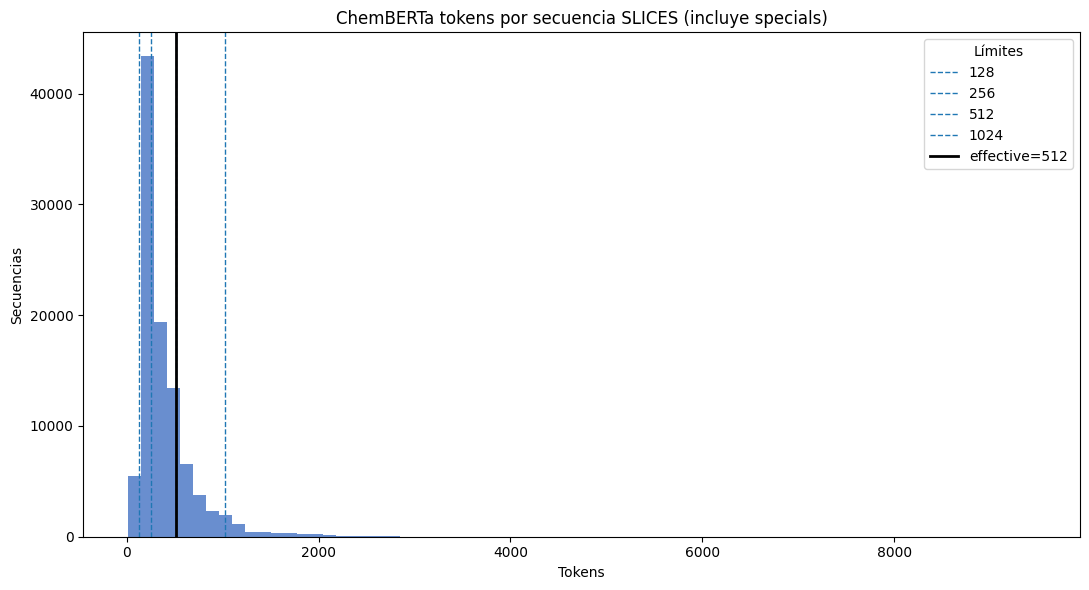

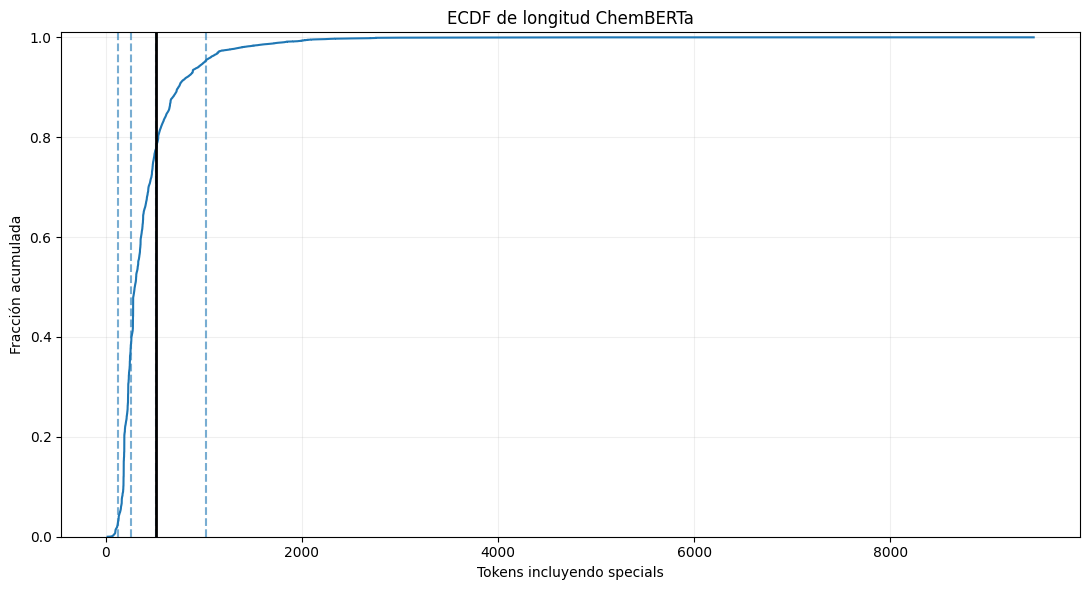

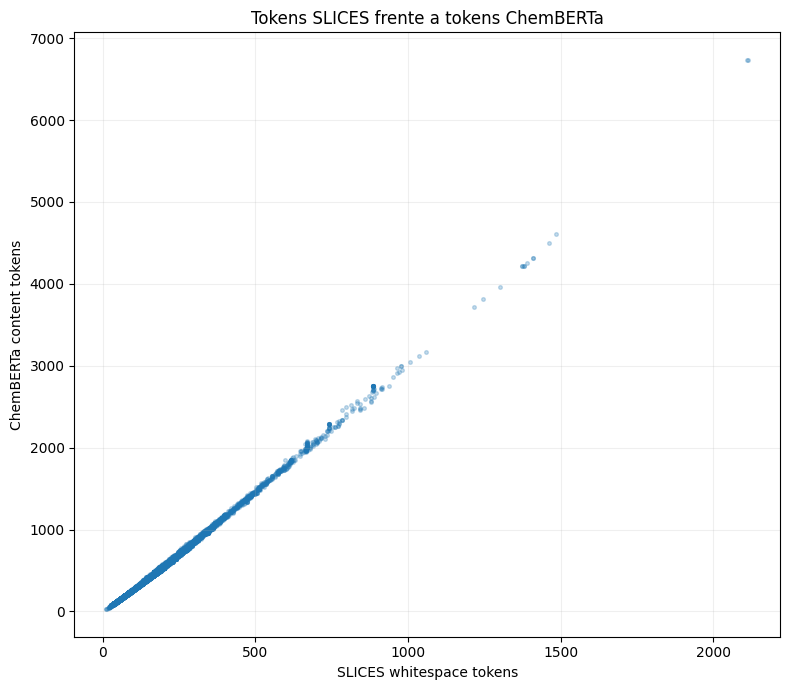

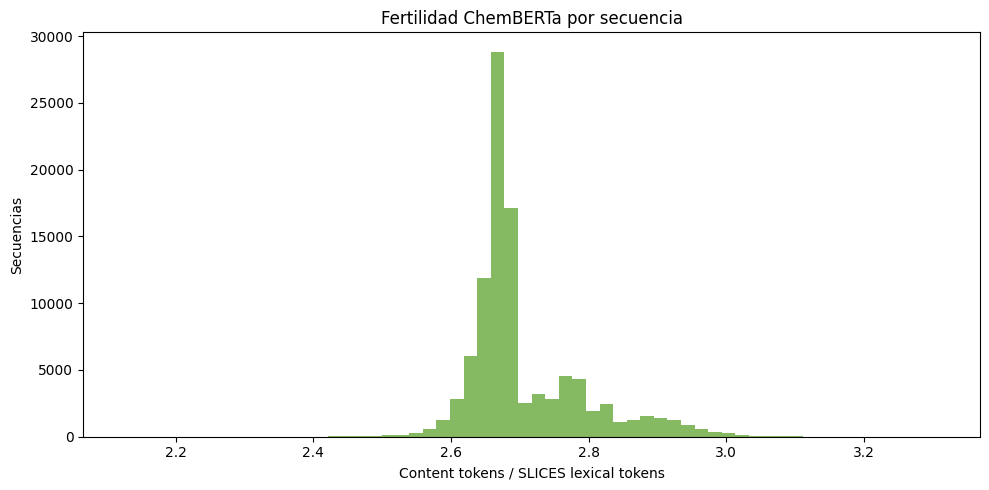

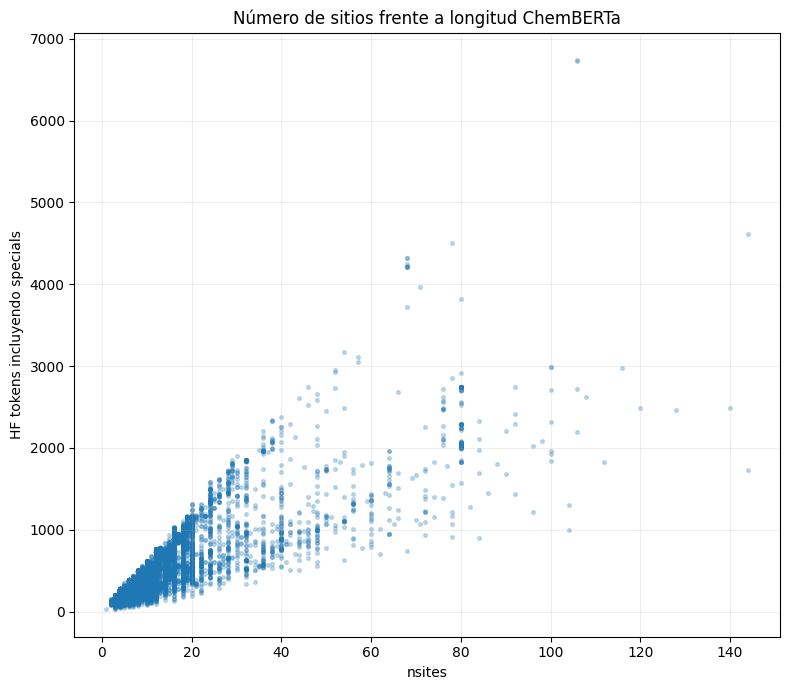

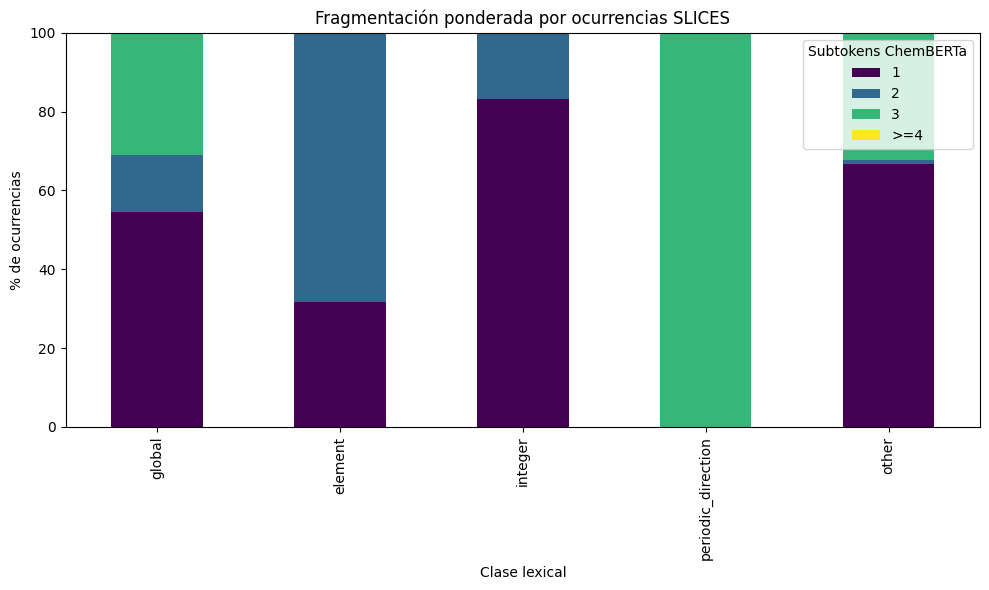

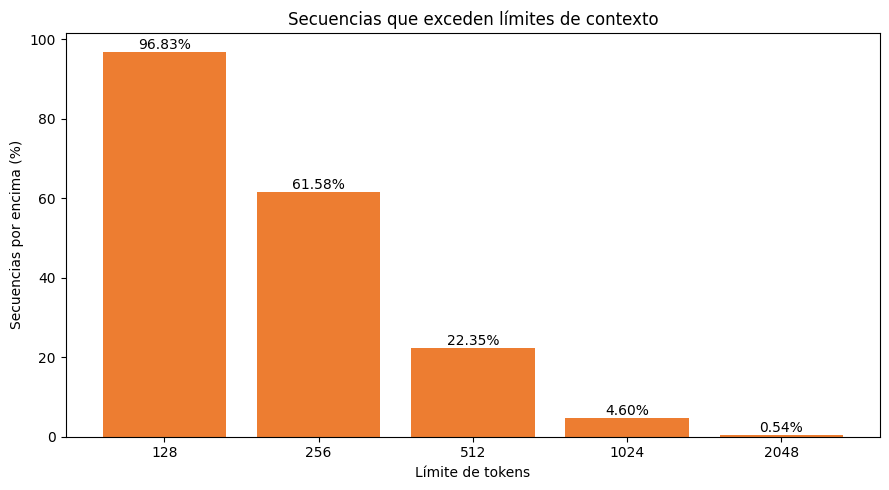

In [21]:
# 01: histograma de longitud full-sequence y líneas de referencia.
fig,ax=plt.subplots(figsize=(11,6))
ax.hist(df_audit["hf_tokens_with_special"],bins=70,color="#4472C4",alpha=.8)
for threshold in [128,256,512,1024]: ax.axvline(threshold,linestyle="--",linewidth=1,label=str(threshold))
if effective_context_limit is not None: ax.axvline(effective_context_limit,color="black",linewidth=2,label=f"effective={effective_context_limit}")
ax.set(title="ChemBERTa tokens por secuencia SLICES (incluye specials)",xlabel="Tokens",ylabel="Secuencias")
ax.legend(title="Límites")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"01_hf_token_length_histogram.png",dpi=160); plt.show()

# 02: ECDF de longitudes: para cualquier x, y es el porcentaje acumulado <= x.
sorted_lengths=np.sort(df_audit["hf_tokens_with_special"].to_numpy())
ecdf=np.arange(1,len(sorted_lengths)+1)/len(sorted_lengths) if len(sorted_lengths) else np.array([])
fig,ax=plt.subplots(figsize=(11,6)); ax.plot(sorted_lengths,ecdf,linewidth=1.5)
for threshold in [128,256,512,1024]: ax.axvline(threshold,linestyle="--",alpha=.6)
if effective_context_limit is not None: ax.axvline(effective_context_limit,color="black",linewidth=2)
ax.set(title="ECDF de longitud ChemBERTa",xlabel="Tokens incluyendo specials",ylabel="Fracción acumulada",ylim=(0,1.01))
ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"02_hf_token_length_ecdf.png",dpi=160); plt.show()

# 03: relación entre tokens lexicales y piezas ChemBERTa; muestra reproducible para visualización.
scatter_df=df_audit.sample(n=min(20_000,len(df_audit)),random_state=RANDOM_SEED) if len(df_audit)>20_000 else df_audit
fig,ax=plt.subplots(figsize=(8,7)); ax.scatter(scatter_df["slices_whitespace_tokens"],scatter_df["hf_tokens_no_special"],s=7,alpha=.25)
ax.set(title="Tokens SLICES frente a tokens ChemBERTa",xlabel="SLICES whitespace tokens",ylabel="ChemBERTa content tokens")
ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"03_slices_vs_chemberta_tokens.png",dpi=160); plt.show()

# 04: distribución de fertilidad por secuencia.
fig,ax=plt.subplots(figsize=(10,5)); ax.hist(df_audit["tokenizer_fertility"],bins=60,color="#70AD47",alpha=.85)
ax.set(title="Fertilidad ChemBERTa por secuencia",xlabel="Content tokens / SLICES lexical tokens",ylabel="Secuencias")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"04_tokenizer_fertility_histogram.png",dpi=160); plt.show()

# 05: tamaño cristalino frente a longitud; muestra reproducible si hay muchas filas.
fig,ax=plt.subplots(figsize=(8,7))
if "nsites" in df_audit.columns:
    ax.scatter(scatter_df["nsites"],scatter_df["hf_tokens_with_special"],s=7,alpha=.25)
ax.set(title="Número de sitios frente a longitud ChemBERTa",xlabel="nsites",ylabel="HF tokens incluyendo specials")
ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"05_nsites_vs_hf_tokens.png",dpi=160); plt.show()

# 06: barras apiladas con ocurrencias lexicales por fragmentación y clase.
pivot=fragmentation_by_token_type.pivot(index="token_type",columns="subtoken_count_group",values="percentage_of_type_occurrences").fillna(0)
pivot=pivot.reindex(["global","element","integer","periodic_direction","other"])
fig,ax=plt.subplots(figsize=(10,6)); pivot.plot(kind="bar",stacked=True,ax=ax,colormap="viridis")
ax.set(title="Fragmentación ponderada por ocurrencias SLICES",xlabel="Clase lexical",ylabel="% de ocurrencias",ylim=(0,100))
ax.legend(title="Subtokens ChemBERTa"); fig.tight_layout(); fig.savefig(OUTPUT_DIR/"06_fragmentation_by_token_type.png",dpi=160); plt.show()

# 07: porcentaje de secuencias sobre umbrales.
plot_limits=[128,256,512,1024,2048]
over_percent=[100*float((df_audit["hf_tokens_with_special"]>limit).mean()) for limit in plot_limits]
fig,ax=plt.subplots(figsize=(9,5)); bars=ax.bar([str(x) for x in plot_limits],over_percent,color="#ED7D31")
ax.bar_label(bars,fmt="%.2f%%"); ax.set(title="Secuencias que exceden límites de contexto",xlabel="Límite de tokens",ylabel="Secuencias por encima (%)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR/"07_sequences_over_threshold.png",dpi=160); plt.show()


## 22. Save audit artifacts

Esta sección produce las tablas pedidas, ejemplos de secuencias, reportes de fragmentación y las versiones comprimidas/no comprimidas del audit por secuencia. No se instala `pyarrow`: si no está disponible, el parquet se sustituye por CSV gzip. Todas las rutas están bajo `audit/notebooks/outputs/` o una subcarpeta `run_...` cuando se evita sobrescribir.

In [22]:
if SAMPLE_DATASET_PATH.suffix==".parquet":
    # La ruta base se actualiza al directorio de ejecución si se creó uno.
    sample_path=OUTPUT_DIR/"tokenizer_audit_samples.parquet"
    try:
        tokenizer_audit_samples.to_parquet(sample_path,index=False)
    except (ImportError,ModuleNotFoundError):
        sample_path=OUTPUT_DIR/"tokenizer_audit_samples.csv.gz"
        tokenizer_audit_samples.to_csv(sample_path,index=False,compression="gzip")
else:
    sample_path=OUTPUT_DIR/"tokenizer_audit_samples.csv.gz"
    tokenizer_audit_samples.to_csv(sample_path,index=False,compression="gzip")

output_tables={
    "tokenizer_length_statistics.csv":tokenizer_length_statistics,
    "length_thresholds.csv":length_thresholds,
    "truncation_impact.csv":truncation_impact,
    "length_by_nsites.csv":length_by_nsites,
    "top_slices_tokens.csv":top_slices_tokens,
    "top_chemberta_tokens.csv":top_chemberta_tokens,
    "slices_token_fragmentation.csv":slices_token_fragmentation,
    "fragmentation_by_token_type.csv":fragmentation_by_token_type,
    "candidate_tokens_to_add.csv":candidate_tokens_to_add,
    "longest_sequences.csv":longest_sequences,
    "worst_fragmentation_examples.csv":worst_fragmentation_examples,
    "unknown_token_examples.csv":unknown_token_examples,
    "length_size_correlations.csv":length_size_correlations,
    "integer_magnitude_fragmentation.csv":integer_magnitude_summary,
    "element_fragmentation.csv":element_fragmentation,
    "periodic_direction_fragmentation.csv":periodic_tokens,
}
for filename,table in output_tables.items():
    table.to_csv(OUTPUT_DIR/filename,index=False)


## 23. Core metrics and JSON reproducibility summary

El CSV de métricas nucleares está en formato largo `metric/value`, adecuado para comparar ejecuciones. El JSON conserva dataset, modelo y revisión del tokenizer, límites de contexto, longitudes, fertilidad, UNK, cobertura y versiones de software. El valor de UNK queda `null` si el tokenizer no define `unk_token_id`; eso significa que esa señal no está disponible, no que se haya demostrado una tasa cero.

In [23]:
def percent_over(limit):
    return 100*float((df_audit["hf_tokens_with_special"]>limit).mean()) if len(df_audit) else 0.0

def safe_quantile(values,q):
    return float(np.quantile(values,q)) if len(values) else None

core_metric_values={
    "total_slices_sequences":int(len(df_audit)),
    "total_slices_lexical_tokens":int(total_slices_lexical_tokens),
    "total_chemberta_content_tokens":int(content_lengths.sum()),
    "total_chemberta_tokens_with_special":int(full_lengths.sum()),
    "global_weighted_fertility":global_weighted_fertility,
    "mean_per_sequence_fertility":mean_sequence_fertility,
    "median_sequence_fertility":median_fertility,
    "p90_sequence_fertility":p90_fertility,
    "p95_sequence_fertility":p95_fertility,
    "p99_sequence_fertility":p99_fertility,
    "max_sequence_fertility":max_fertility,
    "mean_hf_tokens_with_special":float(np.mean(full_lengths)) if len(full_lengths) else None,
    "median_hf_tokens_with_special":safe_quantile(full_lengths,.50),
    "p95_hf_tokens_with_special":safe_quantile(full_lengths,.95),
    "p99_hf_tokens_with_special":safe_quantile(full_lengths,.99),
    "max_hf_tokens_with_special":int(np.max(full_lengths)) if len(full_lengths) else None,
    "total_unk_tokens":total_unk_tokens,
    "sequences_with_unk":sequences_with_unk_count,
    "percent_sequences_with_unk":unk_sequence_percent,
    "unk_fraction_global":unk_fraction_global,
    "percent_over_128":percent_over(128),
    "percent_over_256":percent_over(256),
    "percent_over_512":percent_over(512),
    "percent_over_1024":percent_over(1024),
    "percent_over_effective_context":percent_over(effective_context_limit) if effective_context_limit is not None else None,
    "effective_context_limit":effective_context_limit,
    "vocab_size":vocab_size,
    "unique_slices_tokens":n_unique_slices_tokens,
    "unique_chemberta_content_tokens_observed":int(n_unique_chemberta_tokens_used),
    "vocabulary_observed_percent":vocab_coverage_percent,
    "elements_one_token_occurrence_percent":element_one_token_percent,
    "periodic_one_token_occurrence_percent":periodic_one_token_percent,
    "integers_one_token_occurrence_percent":integer_one_token_percent,
}
tokenizer_core_metrics=pd.DataFrame([{"metric":key,"value":value} for key,value in core_metric_values.items()])
tokenizer_core_metrics.to_csv(OUTPUT_DIR/"tokenizer_core_metrics.csv",index=False)

special_token_data={row["token_name"]:{"token":row["token"],"token_id":row["token_id"]}
                    for row in special_tokens_table.to_dict(orient="records")}

def json_scalar(value):
    if value is None or pd.isna(value): return None
    if isinstance(value,(np.integer,)): return int(value)
    if isinstance(value,(np.floating,)): return float(value)
    return value

tokenizer_audit_summary={
    "dataset":str(INPUT_CSV),
    "n_sequences":int(len(df_audit)),
    "n_input_rows":int(len(df)),
    "model_name":MODEL_NAME,
    "model_revision_requested":MODEL_REVISION,
    "tokenizer_revision_resolved":getattr(tokenizer,"init_kwargs",{}).get("_commit_hash"),
    "tokenizer_class":tokenizer.__class__.__name__,
    "vocab_size":vocab_size,
    "special_tokens":special_token_data,
    "tokenizer_model_max_length":json_scalar(tokenizer_model_max_length),
    "config_max_position_embeddings":json_scalar(config_max_position_embeddings),
    "effective_context_limit":effective_context_limit,
    "mean_hf_tokens":core_metric_values["mean_hf_tokens_with_special"],
    "median_hf_tokens":core_metric_values["median_hf_tokens_with_special"],
    "p95_hf_tokens":core_metric_values["p95_hf_tokens_with_special"],
    "p99_hf_tokens":core_metric_values["p99_hf_tokens_with_special"],
    "max_hf_tokens":core_metric_values["max_hf_tokens_with_special"],
    "global_fertility":global_weighted_fertility,
    "mean_per_sequence_fertility":mean_sequence_fertility,
    "median_fertility":median_fertility,
    "p95_fertility":p95_fertility,
    "total_unk":total_unk_tokens,
    "unk_token_id_available":unk_token_id is not None,
    "sequences_with_unk":sequences_with_unk_count,
    "percent_sequences_with_unk":unk_sequence_percent,
    "percent_over_128":percent_over(128),
    "percent_over_256":percent_over(256),
    "percent_over_512":percent_over(512),
    "percent_over_1024":percent_over(1024),
    "percent_over_effective_context":percent_over(effective_context_limit) if effective_context_limit is not None else None,
    "n_unique_slices_tokens":n_unique_slices_tokens,
    "n_unique_chemberta_tokens_used":int(n_unique_chemberta_tokens_used),
    "vocabulary_observed_percent":vocab_coverage_percent,
    "python_version":sys.version,
    "transformers_version":transformers.__version__,
    "pandas_version":pd.__version__,
    "numpy_version":np.__version__,
    "random_seed":RANDOM_SEED,
    "batch_size":BATCH_SIZE,
    "truncation":False,
    "padding":False,
    "energy_targets_loaded":False,
}
with (OUTPUT_DIR/"tokenizer_audit_summary.json").open("w",encoding="utf-8") as handle:
    json.dump(tokenizer_audit_summary,handle,ensure_ascii=False,indent=2,default=json_scalar)


## 24. Recommendation for DAPT and final interpretation

La recomendación se construye con señales conjuntas: `[UNK]`, fertilidad ponderada, fragmentación de jimages/elementos enteros y secuencias que exceden el contexto. Los cortes siguientes son heurísticos para orientar revisión, no leyes científicas. Un tokenizer byte-level puede tener cero `[UNK]` y aun así fragmentar mal unidades SLICES recurrentes. La decisión definitiva requiere evaluar consumo de contexto y objetivos de DAPT, sin entrenar todavía.

In [24]:
percent_over_512=percent_over(512)
percent_over_1024=percent_over(1024)
unk_rate=(unk_sequence_percent if unk_sequence_percent is not None else 0.0)
frequent_fragmented_occurrence_share=100*float(
    candidate_tokens_to_add["frequency"].sum()/total_slices_lexical_tokens
) if total_slices_lexical_tokens else 0.0

if (unk_token_id is not None and unk_rate>=1.0) or global_weighted_fertility>=2.5 or frequent_fragmented_occurrence_share>=20:
    recommendation="Tokenizer adaptation or retraining should be evaluated before DAPT."
elif (unk_rate==0 and global_weighted_fertility<=1.5 and percent_over_512<=5
      and (effective_context_limit is None or percent_over(effective_context_limit)<=5)):
    recommendation="The existing ChemBERTa tokenizer appears usable for SLICES DAPT."
else:
    recommendation="ChemBERTa tokenizer may be reusable, but sequence length and/or fragmentation require mitigation."

print("============================================================")
print("CHEMBERTA → SLICES TOKENIZER AUDIT")
print("============================================================")
print("Dataset:")
print(f"  Sequences:                         {len(df_audit):>10}")
print("\nTokenizer:")
print(f"  Model:                             {MODEL_NAME}")
print(f"  Class:                             {tokenizer.__class__.__name__}")
print(f"  Vocabulary size:                   {vocab_size:>10}")
print(f"  Effective context window:          {effective_context_limit}")
print("\nSequence length (with special tokens):")
print(f"  Median HF tokens:                  {np.median(full_lengths):.1f}")
print(f"  P95:                               {np.quantile(full_lengths,.95):.1f}")
print(f"  P99:                               {np.quantile(full_lengths,.99):.1f}")
print(f"  Maximum:                           {np.max(full_lengths):.0f}")
print("\nContext overflow:")
for threshold in [128,256,512,1024]: print(f"  >{threshold}:                              {percent_over(threshold):.2f} %")
print(f"  >effective limit:                  {percent_over(effective_context_limit):.2f} %" if effective_context_limit else "  >effective limit:                  no determinado")
print("\nFragmentation:")
print(f"  Global weighted fertility:         {global_weighted_fertility:.3f}")
print(f"  Mean per-sequence fertility:       {mean_sequence_fertility:.3f}")
print(f"  Median fertility:                  {median_fertility:.3f}")
print(f"  P95 fertility:                     {p95_fertility:.3f}")
print("\nUnknown tokens:")
print(f"  Total UNK:                         {total_unk_tokens if total_unk_tokens is not None else 'not available'}")
print(f"  Sequences with UNK:                {sequences_with_unk_count if sequences_with_unk_count is not None else 'not available'}")
print(f"  % sequences with UNK:              {unk_sequence_percent:.2f} %" if unk_sequence_percent is not None else "  % sequences with UNK:              not available")
print("\nVocabulary:")
print(f"  Unique SLICES tokens:              {n_unique_slices_tokens:>10}")
print(f"  ChemBERTa vocabulary tokens used:  {n_unique_chemberta_tokens_used:>10}")
print("\nCore lexical fragmentation (% occurrences mapped to one token):")
print(f"  Elements:                          {element_one_token_percent:.2f} %" if not np.isnan(element_one_token_percent) else "  Elements:                          not available")
print(f"  Periodic tokens:                   {periodic_one_token_percent:.2f} %" if not np.isnan(periodic_one_token_percent) else "  Periodic tokens:                   not available")
print(f"  Integer tokens:                    {integer_one_token_percent:.2f} %" if not np.isnan(integer_one_token_percent) else "  Integer tokens:                    not available")
print("\nRecommendation:")
print(" ",recommendation)
print("\nOutputs:",OUTPUT_DIR)


CHEMBERTA → SLICES TOKENIZER AUDIT
Dataset:
  Sequences:                              99998

Tokenizer:
  Model:                             seyonec/ChemBERTa-zinc-base-v1
  Class:                             RobertaTokenizer
  Vocabulary size:                          767
  Effective context window:          512

Sequence length (with special tokens):
  Median HF tokens:                  296.0
  P95:                               1004.0
  P99:                               1807.1
  Maximum:                           9463

Context overflow:
  >128:                              96.83 %
  >256:                              61.58 %
  >512:                              22.35 %
  >1024:                              4.60 %
  >effective limit:                  22.35 %

Fragmentation:
  Global weighted fertility:         2.758
  Mean per-sequence fertility:       2.705
  Median fertility:                  2.676
  P95 fertility:                     2.895

Unknown tokens:
  Total UNK:           

## Interpretación final

El notebook responde con métricas a la pregunta de si el tokenizer representa las cadenas SLICES con eficiencia suficiente para evaluar DAPT. Revisa conjuntamente la longitud, el overflows, la fertilidad y las clases lexicales. Un elemento de tabla periódica fragmentado no pesa lo mismo que un delimitador infrecuente; por eso se reportan frecuencias y no solo vocabulario único.

La recomendación automática es orientativa y queda registrada en el JSON/resumen impreso. La decisión del próximo paso debe comparar: (A) tokenizer ChemBERTa original, (B) posible extensión futura de vocabulario, o (C) tokenizer SLICES dedicado. **No se ejecuta ninguna de esas acciones aquí.**
